In [2]:
import numpy as np

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from sklearn.preprocessing import MultiLabelBinarizer

import librosa
import librosa.display
import soundfile as sf

from IPython.display import Markdown

from pathlib import Path
from birdclef_2026_ml.notebooks.notebook_utils import init_notebook
from birdclef_2026_ml.notebooks.eda import *
from birdclef_2026_ml.processing.audio_utils import load_train_audio, compute_rms_dbfs
from birdclef_2026_ml.feature_engineering.configs import FeatureConfig
from birdclef_2026_ml.paths import PATHS

init_notebook()

In [3]:
cfg = FeatureConfig()
train = pd.read_parquet(PATHS["proc_train"])
soundscapes = pd.read_parquet(PATHS["proc_soundscapes"])
taxonomy = pd.read_csv(PATHS["taxonomy"])
soundscapes

,filename,start,end,primary_label,primary_label_list,datetime,start_sec,end_sec
0,BC2026_Train_0039_S22_20211231_201500.ogg,00:00:00,00:00:05,22961;23158;24321;517063;65380,"[22961, 23158, 24321, 517063, 65380]",2021-12-31 20:15:00,0.0,5.0
1,BC2026_Train_0039_S22_20211231_201500.ogg,00:00:05,00:00:10,22961;23158;24321;517063;65380,"[22961, 23158, 24321, 517063, 65380]",2021-12-31 20:15:00,5.0,10.0
2,BC2026_Train_0039_S22_20211231_201500.ogg,00:00:10,00:00:15,22961;23158;24321;517063;65380,"[22961, 23158, 24321, 517063, 65380]",2021-12-31 20:15:00,10.0,15.0
3,BC2026_Train_0039_S22_20211231_201500.ogg,00:00:15,00:00:20,22961;23158;24321;517063;65380,"[22961, 23158, 24321, 517063, 65380]",2021-12-31 20:15:00,15.0,20.0
4,BC2026_Train_0039_S22_20211231_201500.ogg,00:00:20,00:00:25,22961;23158;24321;517063;65380,"[22961, 23158, 24321, 517063, 65380]",2021-12-31 20:15:00,20.0,25.0
...,...,...,...,...,...,...,...,...
734,BC2026_Train_0055_S22_20220219_200000.ogg,00:00:35,00:00:40,555146;65380,"[555146, 65380]",2022-02-19 20:00:00,35.0,40.0
735,BC2026_Train_0055_S22_20220219_200000.ogg,00:00:40,00:00:45,517063;555146,"[517063, 555146]",2022-02-19 20:00:00,40.0,45.0
736,BC2026_Train_0055_S22_20220219_200000.ogg,00:00:45,00:00:50,517063;555146,"[517063, 555146]",2022-02-19 20:00:00,45.0,50.0
737,BC2026_Train_0055_S22_20220219_200000.ogg,00:00:50,00:00:55,517063;555146;66971,"[517063, 555146, 66971]",2022-02-19 20:00:00,50.0,55.0


### Species type (`class_name`) and frequencies bands

In [17]:
def compute_species_profile(y, cfg, n_mels=128):
    mel = librosa.feature.melspectrogram(y=y, sr=cfg.sr, n_mels=n_mels)
    mel_db = librosa.power_to_db(mel, ref=1.0) 
    species_profile = np.median(mel_db, axis=1)

    dominant = np.argmax(mel_db, axis=0)
    hist = np.bincount(dominant, minlength=mel_db.shape[0])
    hist = hist / hist.sum() # normalize to get probability distribution

    return species_profile, hist


def compute_species_profile_for_group(
    group,
    full_df,
    cfg,
    n_mels=128,
    max_files_per_species=100,
    filename_col="filename",
):
    row_positions = group["row_pos"].head(max_files_per_species).astype(int).tolist()
    profiles = []
    hists = []

    for pos in row_positions:
        y, _ = load_train_audio(full_df, idx=pos, filename_col=filename_col, sr=cfg.sr)
        profile, hist = compute_species_profile(y, cfg, n_mels=n_mels)
        profiles.append(profile)
        hists.append(hist)

    return pd.Series([np.median(np.vstack(profiles), axis=0), np.mean(np.vstack(hists), axis=0)])


In [18]:
train_pos = train.reset_index(drop=True).reset_index(names="row_pos")
species_profiles = (
    train_pos.groupby("class_name")
    .apply(
        compute_species_profile_for_group,
        full_df=train,
        cfg=cfg,
        n_mels=128,
        max_files_per_species=100,
    )
    .rename(columns={0: "species_profile", 1: "species_hist"})
    .reset_index()
)

species_profiles["mel_frequencies"] = species_profiles["species_profile"].apply(
    lambda species_profile: librosa.mel_frequencies(
        n_mels=len(species_profile),
        fmin=0,
        fmax=cfg.sr // 2,
    )
)

In [19]:
plot_df = species_profiles[["class_name", "mel_frequencies", "species_profile", "species_hist"]].copy()
plot_df["mel_frequencies"] = plot_df["mel_frequencies"].apply(lambda x: np.asarray(x).tolist())
plot_df["species_profile"] = plot_df["species_profile"].apply(lambda x: np.asarray(x).tolist())
plot_df["species_hist"] = plot_df["species_hist"].apply(lambda x: np.asarray(x).tolist())

plot_df = plot_df.explode(["mel_frequencies", "species_profile", "species_hist"], ignore_index=True)
plot_df["mel_frequencies"] = plot_df["mel_frequencies"].astype(float)
plot_df["species_profile"] = plot_df["species_profile"].astype(float)
plot_df["species_hist"] = plot_df["species_hist"].astype(float)

##### Energy profile for each species type

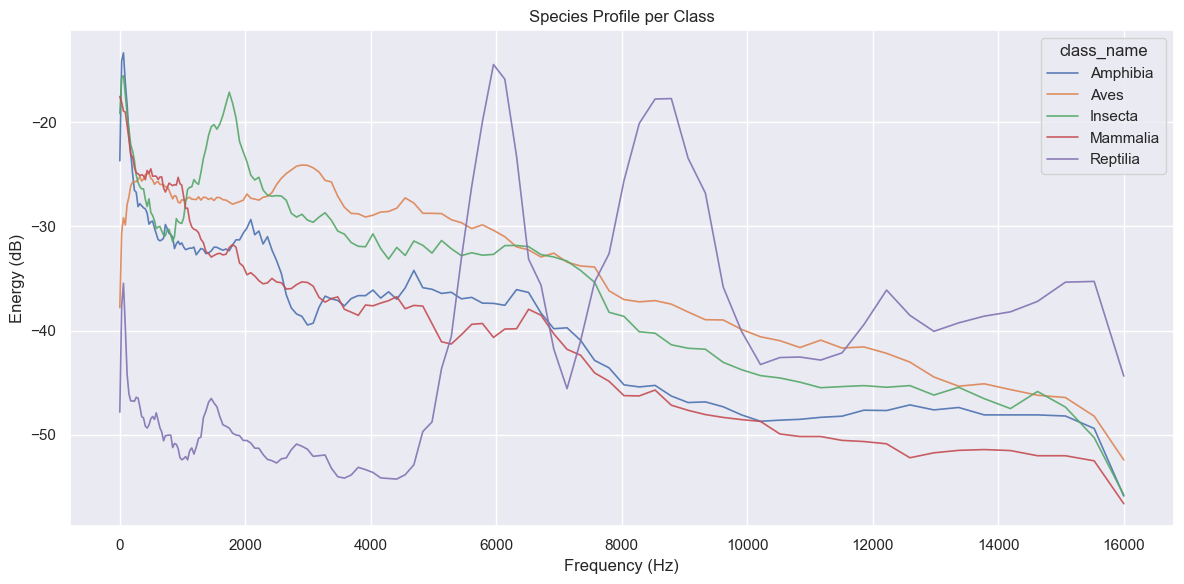

In [20]:
plt.figure(figsize=(12, 6))
sns.lineplot(
    data=plot_df,
    x="mel_frequencies",
    y="species_profile",
    hue="class_name",
    estimator=None,
    sort=False,
    linewidth=1.2,
    alpha=0.9,
    legend="brief",
)
plt.xlabel("Frequency (Hz)")
plt.ylabel("Energy (dB)")
plt.title("Species Profile per Class")
plt.tight_layout()

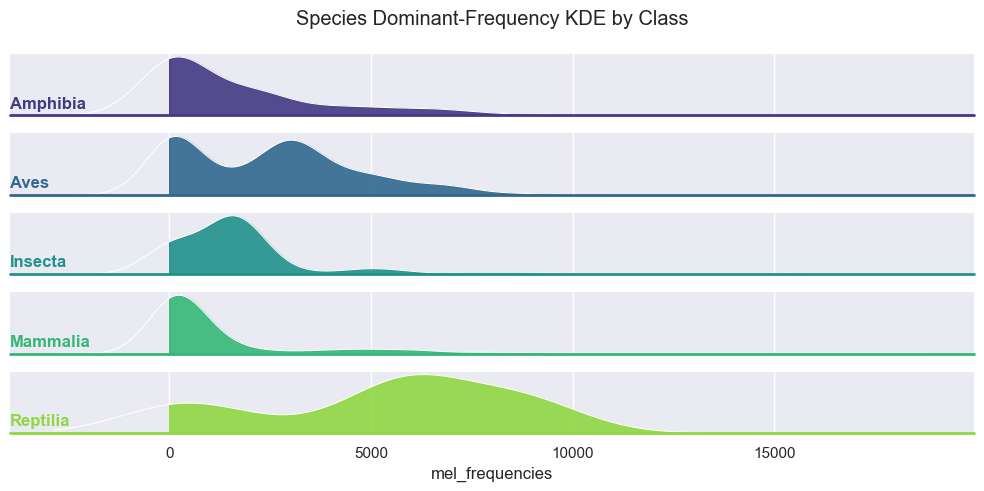

In [53]:
g = sns.FacetGrid(
    plot_df,
    row="class_name",
    hue="class_name",
    aspect=10,
    height=1,
    palette="viridis",
    sharex=True,
    sharey=False,
 )

g.map_dataframe(
    sns.kdeplot,
    x="mel_frequencies",
    weights="species_hist",
    bw_adjust=0.6,
    fill=True,
    alpha=0.9,
    linewidth=1.0,
    common_norm=False,
    clip=(plot_df["mel_frequencies"].min(), plot_df["mel_frequencies"].max()),
)

g.map_dataframe(
    sns.kdeplot,
    x="mel_frequencies",
    weights="species_hist",
    bw_adjust=0.6,
    color="white",
    linewidth=0.8,
    common_norm=False,
 )

g.refline(y=0, linewidth=2, linestyle="-", color=None, clip_on=False)

def label(x, color, label):
    ax = plt.gca()
    ax.text(0, .2, label, fontweight="bold", color=color,
            ha="left", va="center", transform=ax.transAxes)


g.map(label, "mel_frequencies")

# Set the subplots to overlap
#g.figure.subplots_adjust(hspace=-.25)

# Remove axes details that don't play well with overlap
g.set_titles("")
g.figure.suptitle("Species Dominant-Frequency KDE by Class")
g.set(yticks=[], ylabel="")
g.despine(bottom=True, left=True)
plt.tight_layout()

### Profiles per `primary_label`

In [21]:
train_pos = train.reset_index(drop=True).reset_index(names="row_pos")
species_profiles = (
    train_pos.groupby("primary_label")
    .apply(
        compute_species_profile_for_group,
        full_df=train,
        cfg=cfg,
        n_mels=128,
        max_files_per_species=100,
    )
    .rename(columns={0: "species_profile", 1: "species_hist"})
    .reset_index()
)

species_profiles["mel_frequencies"] = species_profiles["species_profile"].apply(
    lambda species_profile: librosa.mel_frequencies(
        n_mels=len(species_profile),
        fmin=0,
        fmax=cfg.sr // 2,
    )
)

In [38]:
species_profiles["mel_frequencies"] = species_profiles["mel_frequencies"].apply(lambda x: np.asarray(x).tolist())
species_profiles["species_profile"] = species_profiles["species_profile"].apply(lambda x: np.asarray(x).tolist())
species_profiles["species_hist"] = species_profiles["species_hist"].apply(lambda x: np.asarray(x).tolist())

species_profiles = species_profiles.explode(["mel_frequencies", "species_profile", "species_hist"], ignore_index=True)
species_profiles["mel_frequencies"] = species_profiles["mel_frequencies"].astype(float)
species_profiles["species_profile"] = species_profiles["species_profile"].astype(float)
species_profiles["species_hist"] = species_profiles["species_hist"].astype(float)

<Axes: xlabel='mel_frequencies', ylabel='species_profile'>

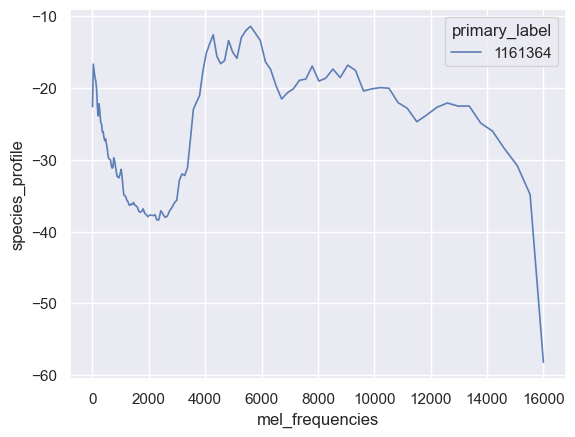

In [39]:
profiles = species_profiles[species_profiles["primary_label"].isin(['1161364'])]

sns.lineplot(
        data=profiles,
        x="mel_frequencies",
        y="species_profile",
        hue="primary_label",
        estimator=None,
        sort=False,
        linewidth=1.2,
        alpha=0.9,
        legend="brief",
    )

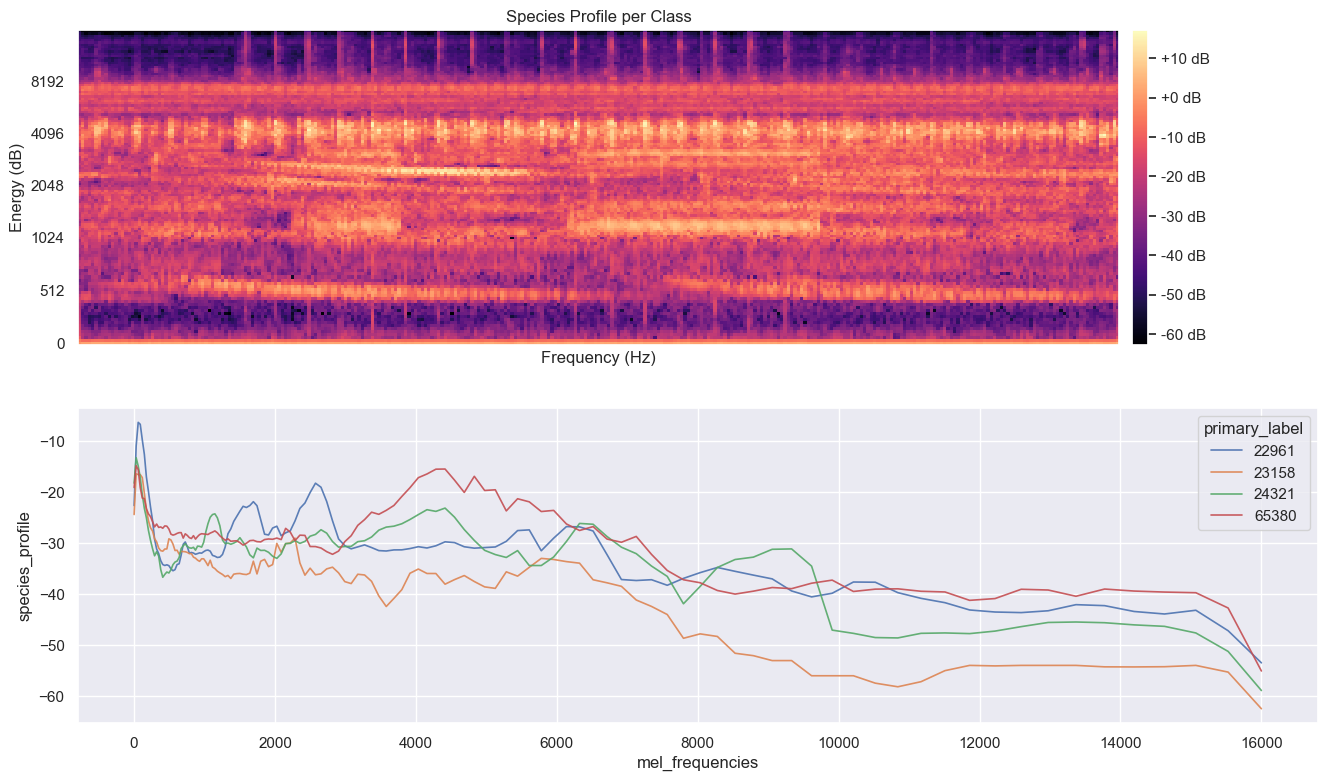

In [44]:
fig = plot_soundscape_window_with_profiles(soundscapes,
                                           species_profiles,
                                           "BC2026_Train_0039_S22_20211231_201500.ogg",
                                           start=0,
                                           end=5)

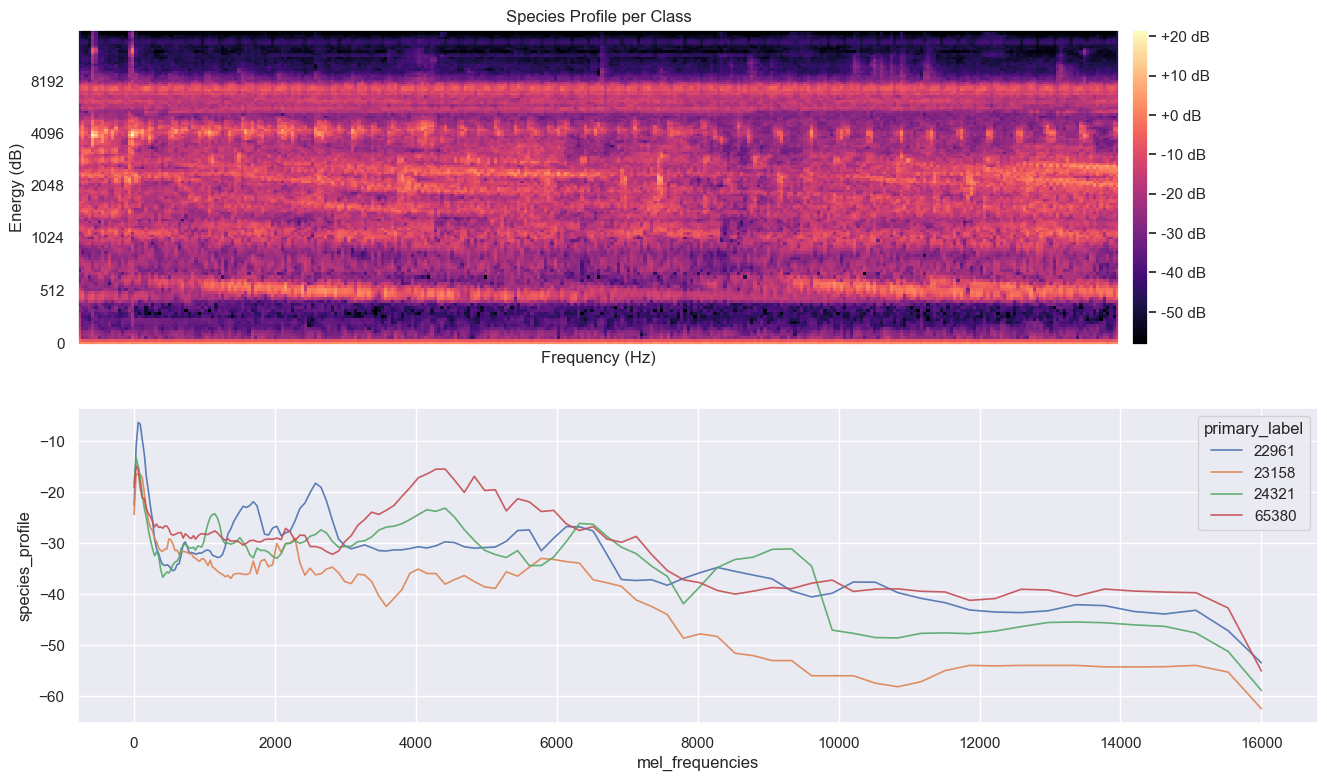

In [45]:
fig = plot_soundscape_window_with_profiles(soundscapes,
                                           species_profiles,
                                           "BC2026_Train_0039_S22_20211231_201500.ogg",
                                           start=10,
                                           end=15)

In [33]:
soundscapes

,filename,start,end,primary_label,primary_label_list,datetime,start_sec,end_sec
0,BC2026_Train_0039_S22_20211231_201500.ogg,00:00:00,00:00:05,22961;23158;24321;517063;65380,"[22961, 23158, 24321, 517063, 65380]",2021-12-31 20:15:00,0.0,5.0
1,BC2026_Train_0039_S22_20211231_201500.ogg,00:00:05,00:00:10,22961;23158;24321;517063;65380,"[22961, 23158, 24321, 517063, 65380]",2021-12-31 20:15:00,5.0,10.0
2,BC2026_Train_0039_S22_20211231_201500.ogg,00:00:10,00:00:15,22961;23158;24321;517063;65380,"[22961, 23158, 24321, 517063, 65380]",2021-12-31 20:15:00,10.0,15.0
3,BC2026_Train_0039_S22_20211231_201500.ogg,00:00:15,00:00:20,22961;23158;24321;517063;65380,"[22961, 23158, 24321, 517063, 65380]",2021-12-31 20:15:00,15.0,20.0
4,BC2026_Train_0039_S22_20211231_201500.ogg,00:00:20,00:00:25,22961;23158;24321;517063;65380,"[22961, 23158, 24321, 517063, 65380]",2021-12-31 20:15:00,20.0,25.0
...,...,...,...,...,...,...,...,...
734,BC2026_Train_0055_S22_20220219_200000.ogg,00:00:35,00:00:40,555146;65380,"[555146, 65380]",2022-02-19 20:00:00,35.0,40.0
735,BC2026_Train_0055_S22_20220219_200000.ogg,00:00:40,00:00:45,517063;555146,"[517063, 555146]",2022-02-19 20:00:00,40.0,45.0
736,BC2026_Train_0055_S22_20220219_200000.ogg,00:00:45,00:00:50,517063;555146,"[517063, 555146]",2022-02-19 20:00:00,45.0,50.0
737,BC2026_Train_0055_S22_20220219_200000.ogg,00:00:50,00:00:55,517063;555146;66971,"[517063, 555146, 66971]",2022-02-19 20:00:00,50.0,55.0


In [16]:
pd.to_timedelta(str(soundscapes["end"].iloc[-1])).total_seconds()

60.0

### Silence detection, RMS

In [7]:
train

,primary_label,secondary_labels,type,latitude,longitude,scientific_name,common_name,class_name,inat_taxon_id,author,license,rating,url,filename,collection,duration
0,1161364,[],[],-22.7562,-46.8666,Guyalna cuta,Guyalna cuta,Insecta,1161364,Lucas Barbosa,cc-by-nc,NaN,https://static.inaturalist.org/sounds/1216197....,1161364/iNat1216197.ogg,iNat,18.024000
1,1161364,[],[],-22.7558,-46.8700,Guyalna cuta,Guyalna cuta,Insecta,1161364,Lucas Barbosa,cc-by-nc,NaN,https://static.inaturalist.org/sounds/1114648....,1161364/iNat1114648.ogg,iNat,28.392000
2,1161364,[],[],-22.7547,-46.8728,Guyalna cuta,Guyalna cuta,Insecta,1161364,Lucas Barbosa,cc-by-nc,NaN,https://static.inaturalist.org/sounds/810195.m...,1161364/iNat810195.ogg,iNat,80.016000
3,1161364,[],[],-22.7547,-46.8728,Guyalna cuta,Guyalna cuta,Insecta,1161364,Lucas Barbosa,cc-by-nc,NaN,https://static.inaturalist.org/sounds/818781.m...,1161364/iNat818781.ogg,iNat,61.272000
4,1161364,[],[],-22.7426,-46.8985,Guyalna cuta,Guyalna cuta,Insecta,1161364,Lucas Barbosa,cc-by-nc,NaN,https://static.inaturalist.org/sounds/556514.m...,1161364/iNat556514.ogg,iNat,71.064000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
31986,yeofly1,[],[call],-6.7281,-76.4181,Tolmomyias sulphurescens,Yellow-olive Flatbill,Aves,16567,GABRIEL LEITE,by-nc-sa,4.0,https://xeno-canto.org/762473/download,yeofly1/XC762473.ogg,XC,21.209937
31987,yeofly1,[],"[call, song]",-16.0538,-49.6040,Tolmomyias sulphurescens,Yellow-olive Flatbill,Aves,16567,JAYRSON ARAUJO DE OLIVEIRA,by-nc-sa,5.0,https://xeno-canto.org/818328/download,yeofly1/XC818328.ogg,XC,13.479188
31988,yeofly1,[],[song],5.9002,-74.8485,Tolmomyias sulphurescens,Yellow-olive Flatbill,Aves,16567,Jerome Fischer,by-nc-sa,4.0,https://xeno-canto.org/425545/download,yeofly1/XC425545.ogg,XC,80.039187
31989,yeofly1,[],[song],3.3821,-61.4464,Tolmomyias sulphurescens,Yellow-olive Flatbill,Aves,16567,GABRIEL LEITE,by-nc-sa,4.0,https://xeno-canto.org/456230/download,yeofly1/XC456230.ogg,XC,11.376000


In [8]:
y, _ = load_train_audio(train, 5)
rms, rms_db, times = compute_rms_dbfs(y, cfg)

Detected 4 silence frames


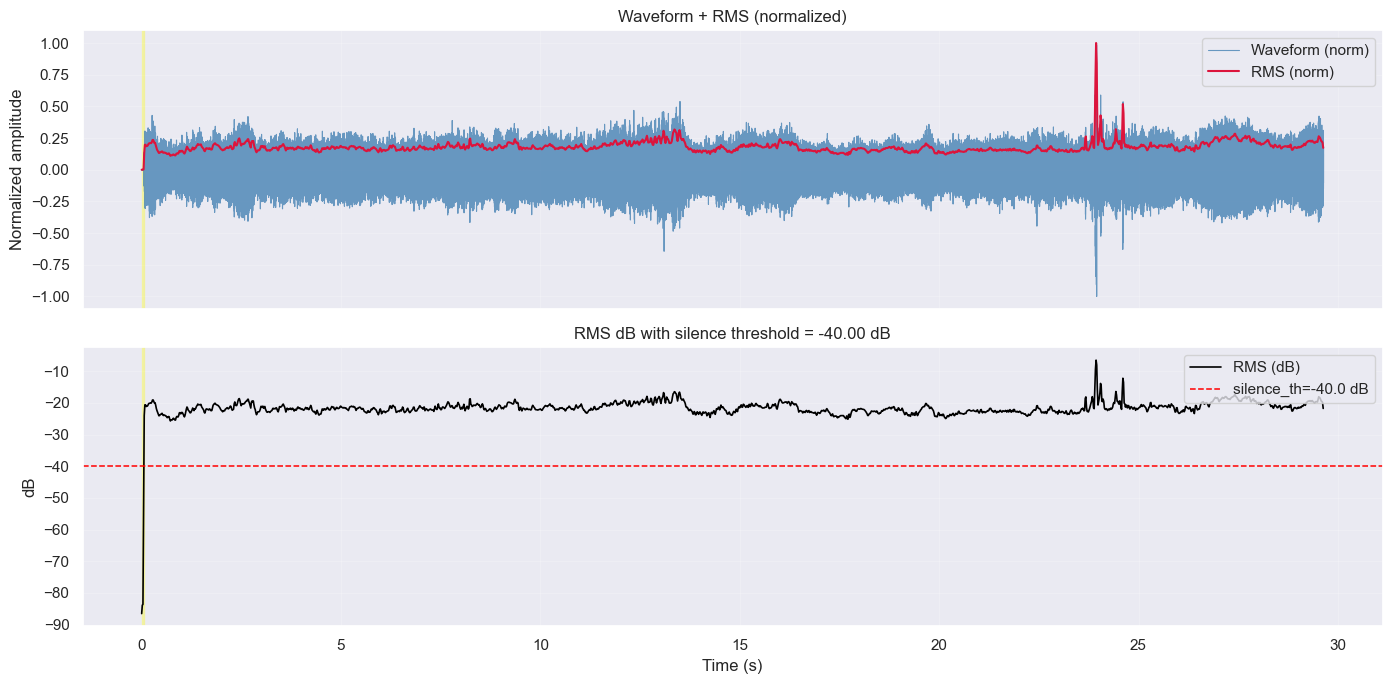

In [9]:

th = np.percentile(rms_db, 10)
fig, axes, silent_seconds, silence_segments = plot_waveform_rms_db_with_silence(
    y=y,
    cfg=cfg,
    silence_th=-40,
)

print(f"Detected {len(silent_seconds)} silence frames")

Detected 231 silence frames


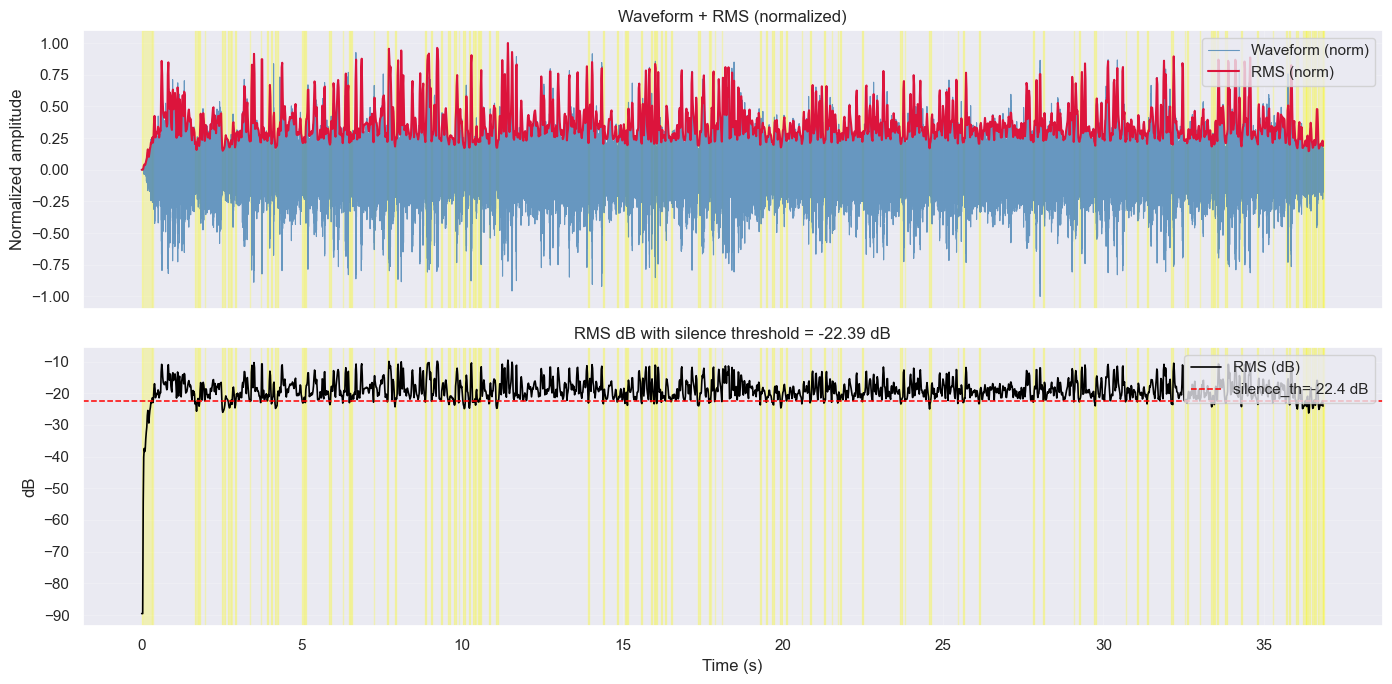

In [51]:
# Percentile assumption (at least x% of frames are silent) -> incorrect one for some files

th = np.percentile(rms_db, 10)
fig, axes, silent_seconds, silence_segments = plot_waveform_rms_db_with_silence(
    y=y,
    cfg=cfg,
    silence_th=th,
)

print(f"Detected {len(silent_seconds)} silence frames")

Detected 346 silence frames


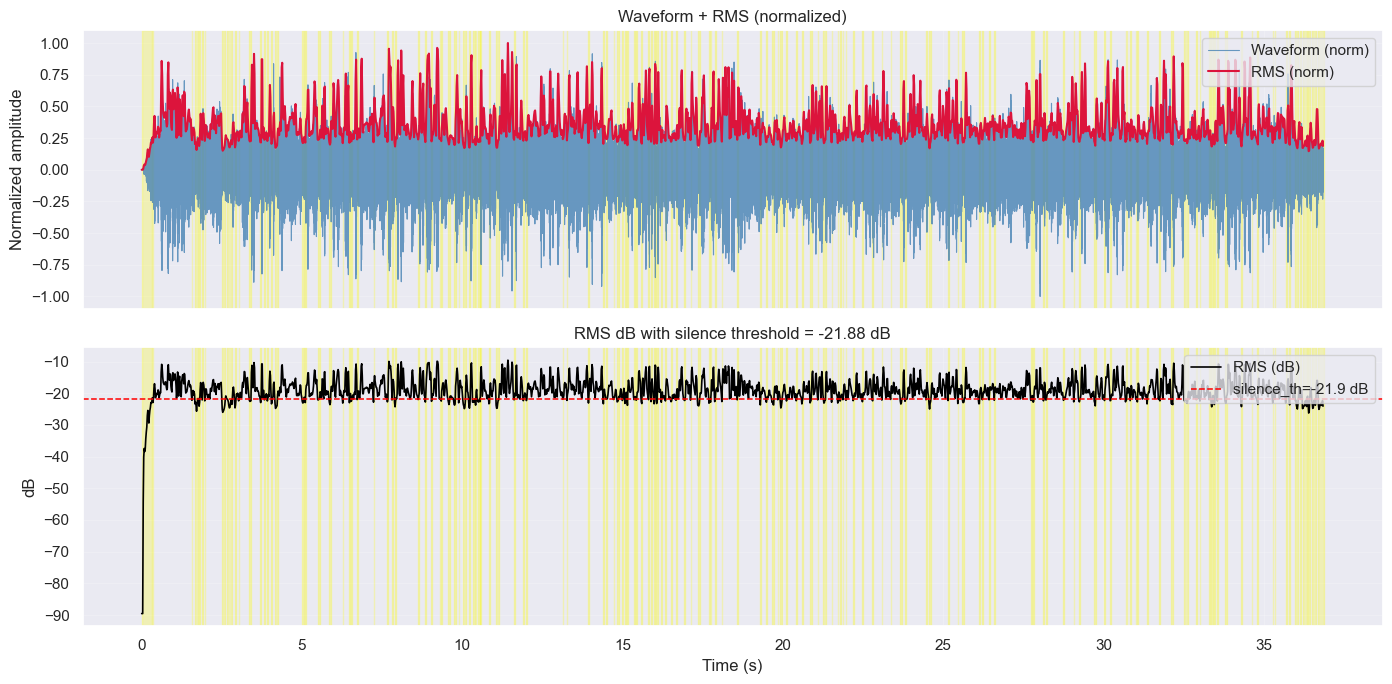

In [52]:
# Low-energy median
low = rms_db[rms_db < np.percentile(rms_db, 30)]
th = np.median(low)

fig, axes, silent_seconds, silence_segments = plot_waveform_rms_db_with_silence(
    y=y,
    cfg=cfg,
    silence_th=th,
)

print(f"Detected {len(silent_seconds)} silence frames")

Detected 240 silence frames


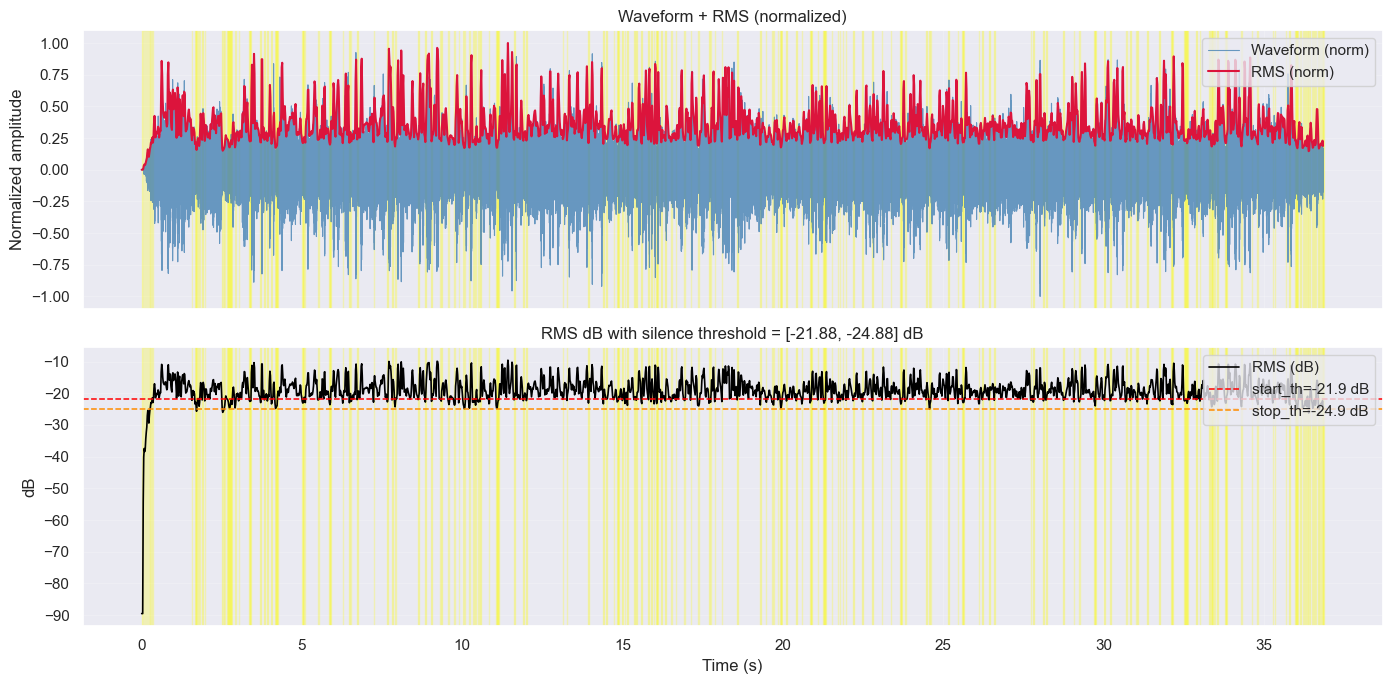

In [53]:
# Low-energy median with hysteresis
low = rms_db[rms_db < np.percentile(rms_db, 30)]
th = np.median(low)

fig, axes, silent_seconds, silence_segments = plot_waveform_rms_db_with_silence(
    y=y,
    cfg=cfg,
    silence_th=None,
    start_th=th,
    stop_th=th-3
)

print(f"Detected {len(silent_seconds)} silence frames")